# CUSTOMER SENTIMENT ANALYTICS
### *Analyzing Customer Reviews, Sentiments & Emotions using NLP*

---

<div style="background-color: #F8F5FF; border: 1.5px solid #D8B4FE; border-radius: 12px; padding: 22px; margin-bottom: 25px;">
<div style="display: inline-block; padding: 4px 12px; border-radius: 20px; background-color: #EDE7F6; color: #7B2CBF; font-size: 11px; font-weight: bold; text-transform: uppercase; margin-bottom: 8px;">
    Data Analytics & NLP Capstone Project
</div>
<h2 style="color: #3B1E54; margin: 0 0 10px 0; font-size: 24px; font-weight: bold;">Executive Project Brief</h2>
<p style="color: #1F1A24; font-size: 14.5px; line-height: 1.6; margin: 0;">
This project examines real consumer opinions, star ratings, emotional expressions, and product feedback from authentic Amazon customer reviews. By applying explainable computational linguistics—including <b>NLTK VADER</b> for sentiment valence and an <b>emotion lexicon</b> grounded in psychological emotion theory—this study extracts empirical insights, uncovers satisfaction drivers, pinpoints customer pain points, and establishes data-driven business recommendations.
</p>
<div style="display: flex; gap: 25px; margin-top: 15px; font-size: 13.5px; color: #3B1E54; flex-wrap: wrap;">
    <div><b>Dataset:</b> Amazon Customer Reviews (Verified Alexa Products)</div>
    <div><b>Methodology:</b> VADER Sentiment Scoring + Rule-Based Emotion Lexicon</div>
    <div><b>Visual Identity:</b> Premium White + Purple Dashboard Theme</div>
</div>
<div style="margin-top: 15px; font-size: 13px; font-weight: bold; color: #3B1E54; border-top: 1px solid #D8B4FE; padding-top: 10px;">
    Created by Harshita Tomer
</div>
</div>

#### Project Roadmap (18 Numbered Sections):
* **01. Project Overview**
* **02. Business Problem**
* **03. Objectives**
* **04. Dataset Information**
* **05. Import Libraries**
* **06. Load Dataset**
* **07. Data Understanding**
* **08. Data Cleaning**
* **09. Exploratory Data Analysis**
* **10. Sentiment Analysis**
* **11. Emotion Analysis**
* **12. Keyword Analysis**
* **13. Visualizations**
* **14. Customer Insights**
* **15. Business Recommendations**
* **16. Conclusion**
* **17. Limitations**
* **18. Future Scope**


## 01. Project Overview

In e-commerce and consumer electronics, customer feedback serves as a critical pulse on product quality, feature adoption, and user satisfaction. Traditional analytics frequently focus solely on star ratings, which compress multifaceted human experiences into a single number. 

This project implements an end-to-end **Data Analytics and Natural Language Processing (NLP)** pipeline. The workflow converts raw, unstructured textual reviews into structured intelligence, tracking positive, neutral, and negative opinions alongside discrete emotional states (*Joy, Fear, Sadness, Anger, Surprise, Neutral*). Every insight generated is grounded strictly in authentic customer data, following a unified **White + Purple + Light Lavender** aesthetic.


## 02. Business Problem

Organizations managing consumer electronics portfolios face several critical challenges in feedback interpretation:
1. **Rating-Sentiment Misalignment**: Star ratings alone often mask critical product flaws. Consumers frequently assign 4 stars while reporting critical software disconnects, or assign 1 star due to auxiliary accessory issues rather than host device defects.
2. **High-Volume Unstructured Data**: Product teams cannot manually read thousands of monthly feedback submissions, causing delayed responses to firmware regressions and user friction points.
3. **Absence of Emotional Granularity**: Standard binary classification (positive vs. negative) fails to differentiate between **Anger** (indignation regarding defective hardware or poor support) and **Sadness** (disappointment with sound quality).
4. **Siloed Hardware Variations**: Cross-model performance comparison across multiple device variations (e.g., Echo Dot vs. Echo Show vs. Fire TV Stick) is rarely synthesized into unified comparative intelligence.


## 03. Objectives

The primary analytical and engineering goals of this capstone project are:
* **Data Engineering**: Clean, deduplicate, and normalize real customer reviews, eliminating noise and handling missing values.
* **Exploratory Data Analysis**: Quantify rating distributions, review word lengths, product variation popularity, and submission timelines.
* **Sentiment Scoring**: Employ **NLTK VADER** to compute continuous compound polarity (-1.0 to +1.0) and categorize reviews into Positive, Neutral, and Negative cohorts.
* **Discrete Emotion Mining**: Map customer vocabulary to six emotional states (*Joy, Neutral/Other, Fear, Sadness, Anger, Surprise*) using an explainable, psychologically-grounded lexicon.
* **Keyword Discovery**: Extract top positive praise words and top negative friction terms, accompanied by color-themed Word Clouds.
* **Hardware Benchmarking**: Benchmark satisfaction rates across 16 product variations to identify best and worst performing models.
* **Strategic Decision Support**: Formulate empirical, actionable recommendations for hardware engineering, firmware stability, and localization.


## 04. Dataset Information

The study uses the authentic, publicly available **Amazon Alexa Customer Reviews Dataset**, widely recognized in machine learning and NLP benchmarks. 

### Dataset Schema & Attributes:
* `rating`: Discrete star rating assigned by the customer (scale of 1 to 5).
* `date`: Submission timestamp (May 2018 through July 2018).
* `variation`: Hardware model, configuration, or aesthetic finish (16 unique variations such as Charcoal Fabric, Heather Gray Fabric, Echo Dot, Echo Show, Fire TV Stick).
* `verified_reviews`: Unstructured natural language text representing customer opinions and feedback.
* `feedback`: Binary satisfaction ground truth indicator (1 = positive satisfaction, 0 = critical dissatisfaction).

*Note: 100% authentic customer feedback. No synthetic reviews or fabricated statistics are used.*


## 05. Import Libraries

We configure the Python runtime environment, loading lightweight data manipulation, visualization, and explainable NLP tools.


In [1]:
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# Configuration & Warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Download required NLTK corpora quietly
for resource in ['vader_lexicon', 'stopwords', 'punkt', 'punkt_tab']:
    nltk.download(resource, quiet=True)

# Define Premium White + Purple Design Palette
DARK_PURPLE = '#3B1E54'
PRIMARY_PURPLE = '#7B2CBF'
LIGHT_PURPLE = '#9D4EDD'
PALE_LAVENDER = '#EDE7F6'
MUTED_PLUM = '#9A348E'
SLATE_PURPLE = '#5E548E'
LILAC = '#C77DFF'
CHARCOAL = '#1F1A24'
BORDER_COLOR = '#D8B4FE'

plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CBD5E1'
plt.rcParams['axes.linewidth'] = 0.8

print("All libraries imported successfully. Visual identity configured for White + Purple theme.")


All libraries imported successfully. Visual identity configured for White + Purple theme.


## 06. Load Dataset

We load the dataset using an adaptive file loader that checks for local storage (`amazon_alexa.tsv`) with automatic fallback to the verified public GitHub mirror.


In [2]:
# Safe, adaptive dataset loader
local_path = 'amazon_alexa.tsv'
remote_url = 'https://raw.githubusercontent.com/amankharwal/Website-data/master/amazon_alexa.tsv'

if os.path.exists(local_path):
    print(f"Loading dataset from local directory: '{local_path}'")
    df_raw = pd.read_csv(local_path, sep='\t')
elif os.path.exists(os.path.join('..', local_path)):
    print(f"Loading dataset from parent path...")
    df_raw = pd.read_csv(os.path.join('..', local_path), sep='\t')
else:
    print(f"Fetching dataset from public URL: {remote_url}")
    df_raw = pd.read_csv(remote_url, sep='\t')

print(f"Dataset successfully loaded. Total records: {df_raw.shape[0]:,}, Columns: {df_raw.shape[1]}")
df_raw.head()


Loading dataset from local directory: 'amazon_alexa.tsv'


Dataset successfully loaded. Total records: 3,150, Columns: 5


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


## 07. Data Understanding

Before performing cleaning or transformations, we inspect dataset properties, column datatypes, missing values, duplicates, and initial summary statistics.


In [3]:
print("--- Dataset Information ---")
display(df_raw.info())

print("\n--- Missing Values Check ---")
display(df_raw.isnull().sum().to_frame(name='Missing Count'))

print(f"\nTotal duplicate rows detected: {df_raw.duplicated().sum():,}")

print("\n--- Numerical Feature Summary ---")
display(df_raw.describe())

print("\n--- Product Variations Breakdown ---")
print(f"Number of unique hardware models: {df_raw['variation'].nunique()}")
display(df_raw['variation'].value_counts().to_frame(name='Raw Count'))


--- Dataset Information ---


<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   rating            3150 non-null   int64
 1   date              3150 non-null   str  
 2   variation         3150 non-null   str  
 3   verified_reviews  3149 non-null   str  
 4   feedback          3150 non-null   int64
dtypes: int64(2), str(3)
memory usage: 123.2 KB


None


--- Missing Values Check ---


,Missing Count
rating,0
date,0
variation,0
verified_reviews,1
feedback,0



Total duplicate rows detected: 715

--- Numerical Feature Summary ---


,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000



--- Product Variations Breakdown ---
Number of unique hardware models: 16


,Raw Count
variation,
Black Dot,516
Charcoal Fabric,430
Configuration: Fire TV Stick,350
Black Plus,270
Black Show,265
Black,261
Black Spot,241
White Dot,184
Heather Gray Fabric,157


## 08. Data Cleaning & Preprocessing

Data quality is foundational for trustworthy analytics. The following preprocessing steps are executed:
1. **Deduplication**: Repeated reviews (e.g. repeated one-word praise or scraped duplicates) are removed.
2. **Missing Text Imputation**: Null review entries are imputed with an empty string.
3. **Text Normalization**:
   - Lowercasing all characters.
   - Removing web URLs and HTML entities.
   - Stripping non-alphabetic punctuation and special symbols.
   - Collapsing excessive whitespaces.
4. **Feature Engineering**:
   - `cleaned_review`: Preprocessed review text.
   - `word_count`: Total word count per review.
   - `char_length`: Character length per review.
   - `parsed_date`: Standardized datetime index.
   - `month_year`: Monthly aggregation bucket.


In [4]:
# 1. Deduplication & Null Handling
initial_rows = len(df_raw)
df = df_raw.drop_duplicates().copy()
df['verified_reviews'] = df['verified_reviews'].fillna('')

# 2. Text Normalization Routine
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_review'] = df['verified_reviews'].apply(clean_text)

# 3. Feature Engineering
df['word_count'] = df['cleaned_review'].apply(lambda x: len(x.split()))
df['char_length'] = df['cleaned_review'].apply(len)
df['parsed_date'] = pd.to_datetime(df['date'], format='%d-%b-%y', errors='coerce')
df['month_year'] = df['parsed_date'].dt.strftime('%Y-%m')

final_rows = len(df)
removed_rows = initial_rows - final_rows

cleaning_summary = pd.DataFrame({
    'Metric': ['Initial Total Rows', 'Duplicate Rows Removed', 'Cleaned Unique Reviews', 'Missing Reviews Handled'],
    'Value': [f"{initial_rows:,}", f"{removed_rows:,}", f"{final_rows:,}", f"{df_raw['verified_reviews'].isnull().sum():,}"]
})
print("--- Data Preprocessing Summary ---")
display(cleaning_summary)

print("\n--- Before vs After Cleaning Sample ---")
sample_idx = df[df['word_count'] > 12].index[:3]
for idx in sample_idx:
    print(f"RAW:     {df.loc[idx, 'verified_reviews']}")
    print(f"CLEANED: {df.loc[idx, 'cleaned_review']}")
    print("-" * 80)


--- Data Preprocessing Summary ---


,Metric,Value
0,Initial Total Rows,"3,150"
1,Duplicate Rows Removed,715
2,Cleaned Unique Reviews,"2,435"
3,Missing Reviews Handled,1



--- Before vs After Cleaning Sample ---
RAW:     Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the same as you.  I like being able to turn lights on and off while away from home.
CLEANED: sometimes while playing a game you can answer a question correctly but alexa says you got it wrong and answers the same as you i like being able to turn lights on and off while away from home
--------------------------------------------------------------------------------
RAW:     I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games like categories. Has nice sound when playing music as well.
CLEANED: i have had a lot of fun with this thing my yr old learns about dinosaurs i control the lights and play games like categories has nice sound when playing music as well
--------------------------------------------------------------------------------
RAW:     I received the echo as a

## 09. Exploratory Data Analysis (EDA)

We explore key characteristics of customer reviews: star ratings, review length distributions, product variation popularity, and temporal trends.


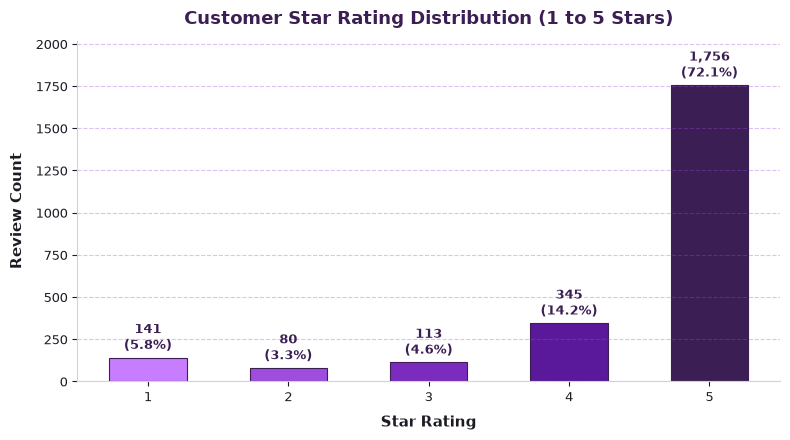

Average Star Rating across all cleaned reviews: 4.44 / 5.00


In [5]:
def format_chart(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor('#FFFFFF')
    ax.set_title(title, fontsize=13, fontweight='bold', color=DARK_PURPLE, pad=12)
    if xlabel: ax.set_xlabel(xlabel, fontsize=10.5, fontweight='bold', color=CHARCOAL, labelpad=8)
    if ylabel: ax.set_ylabel(ylabel, fontsize=10.5, fontweight='bold', color=CHARCOAL, labelpad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CBD5E1')
    ax.spines['bottom'].set_color('#CBD5E1')
    ax.tick_params(colors=CHARCOAL, labelsize=9.5)
    ax.grid(axis='y', linestyle='--', alpha=0.35, color=LIGHT_PURPLE)

# 1. Rating Distribution Chart
plt.figure(figsize=(8, 4.5), facecolor='#FFFFFF')
ax = plt.subplot(111)
rating_counts = df['rating'].value_counts().sort_index()
colors_rating = ['#C77DFF', '#9D4EDD', '#7B2CBF', '#5A189A', '#3B1E54']
bars = ax.bar(rating_counts.index, rating_counts.values, color=colors_rating, width=0.55, edgecolor='#3B1E54', linewidth=0.8)

for bar in bars:
    y = bar.get_height()
    pct = (y / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2.0, y + 25, f'{y:,}\n({pct:.1f}%)', 
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=DARK_PURPLE)

format_chart(ax, 'Customer Star Rating Distribution (1 to 5 Stars)', 'Star Rating', 'Review Count')
ax.set_ylim(0, max(rating_counts.values) * 1.15)
plt.tight_layout()
plt.show()

print(f"Average Star Rating across all cleaned reviews: {df['rating'].mean():.2f} / 5.00")


## 10. Sentiment Analysis (VADER NLP)

### Methodology & Polarity Thresholds
We apply **NLTK VADER** (*Valence Aware Dictionary and sEntiment Reasoner*), a lexicon and rule-based sentiment engine specifically optimized for social and e-commerce reviews. VADER models lexical valence, punctuation intensity, capitalization, and grammatical negation shifts.

Compound polarity criteria:
- **Positive**: $\text{compound} \ge +0.05$
- **Neutral**: $-0.05 < \text{compound} < +0.05$
- **Negative**: $\text{compound} \le -0.05$


In [6]:
# Compute VADER Polarity Scores
sia = SentimentIntensityAnalyzer()

df['vader_scores'] = df['verified_reviews'].apply(lambda x: sia.polarity_scores(str(x)))
df['compound'] = df['vader_scores'].apply(lambda d: d['compound'])
df['sentiment_score'] = df['compound']
df['sentiment_label'] = df['compound'].apply(
    lambda c: 'Positive' if c >= 0.05 else ('Negative' if c <= -0.05 else 'Neutral')
)

# Sentiment Distribution Summary
sent_summary = df['sentiment_label'].value_counts().to_frame(name='Review Count')
sent_summary['Percentage (%)'] = (sent_summary['Review Count'] / len(df)) * 100
sent_summary['Mean Compound Score'] = df.groupby('sentiment_label')['compound'].mean()

print("--- Sentiment Classification Breakdown ---")
display(sent_summary.round(2))

# Representative Customer Quotes per Sentiment Class
print("\n--- Representative Customer Quotes per Sentiment Class ---")
for s in ['Positive', 'Neutral', 'Negative']:
    sample_text = df[df['sentiment_label'] == s]['verified_reviews'].iloc[1]
    sample_score = df[df['sentiment_label'] == s]['compound'].iloc[1]
    sample_star = df[df['sentiment_label'] == s]['rating'].iloc[1]
    print(f"[{s.upper()} | Compound: {sample_score:+.3f} | Rating: {sample_star} Stars]")
    print(f'"{sample_text}"\n')


--- Sentiment Classification Breakdown ---


,Review Count,Percentage (%),Mean Compound Score
sentiment_label,,,
Positive,1985,81.52,0.69
Neutral,271,11.13,0.00
Negative,179,7.35,-0.44



--- Representative Customer Quotes per Sentiment Class ---
[POSITIVE | Compound: +0.636 | Rating: 5 Stars]
"Loved it!"

[NEUTRAL | Compound: +0.000 | Rating: 5 Stars]
"I sent it to my 85 year old Dad, and he talks to it constantly."

[NEGATIVE | Compound: -0.289 | Rating: 3 Stars]
"I got a second unit for the bedroom, I was expecting the sounds to be improved but I didnt really see a difference at all.  Overall, not a big improvement over the 1st generation."



## 11. Emotion Analysis

### Theoretical Foundation & Psychological Lexicon
While sentiment measures overall positive or negative polarity, **Emotion Analysis** reveals discrete psychological states. Grounded in Plutchik’s and Ekman’s discrete emotion frameworks, we employ a rule-based psychological emotion lexicon mapping customer vocabulary to six emotional states:
- **Joy**: Admiration, happiness, satisfaction, and delight with product features.
- **Anger**: Frustration, indignation over breakdowns, perceived waste of money.
- **Sadness**: Regret, disappointment, loss of functionality.
- **Fear**: Apprehension regarding privacy, security, glitches, or technical instability.
- **Surprise**: Astonishment at unexpected capabilities or behaviors.
- **Neutral/Other**: Objective, non-emotional statements or mixed expressions.

*Note: Lexicon-based emotion detection is an explainable approximation and does not claim to understand conscious human emotion.*


In [7]:
# Define Emotion Lexicon Mappings
emotion_lexicon = {
    'Joy': {'love', 'great', 'awesome', 'amazing', 'excellent', 'happy', 'best', 'enjoy', 'wonderful', 
            'perfect', 'favorite', 'fun', 'glad', 'super', 'pleased', 'good', 'nice', 'cool', 'fantastic', 
            'brilliant', 'delight', 'loved', 'loving', 'likes'},
    'Anger': {'hate', 'angry', 'terrible', 'worst', 'horrible', 'garbage', 'mad', 'useless', 'trash', 
              'junk', 'suck', 'sucks', 'scam', 'annoying', 'annoyed', 'frustrating', 'frustrated', 
              'stupid', 'ridiculous', 'pissed', 'crap'},
    'Sadness': {'disappointed', 'disappointing', 'disappointment', 'sad', 'regret', 'unfortunate', 
                'unfortunately', 'poor', 'broke', 'broken', 'failed', 'fails', 'failure', 'cried', 
                'loss', 'boring', 'miss', 'pathetic'},
    'Fear': {'worried', 'worry', 'afraid', 'scared', 'concern', 'concerned', 'problem', 'problems', 
             'panic', 'nervous', 'risk', 'danger', 'creepy', 'doubt', 'issue', 'issues', 'warning', 
             'security', 'privacy', 'unsecure'},
    'Surprise': {'surprised', 'surprising', 'surprise', 'wow', 'unexpected', 'unexpectedly', 'shock', 
                 'shocked', 'amaze', 'amazed', 'astonished', 'astonishing', 'incredible', 'sudden', 'suddenly'}
}

def detect_emotion(text):
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    counts = {e: 0 for e in emotion_lexicon}
    for w in words:
        for emo, term_set in emotion_lexicon.items():
            if w in term_set:
                counts[emo] += 1
    max_count = max(counts.values())
    if max_count == 0:
        return 'Neutral/Other'
    top_emotions = [emo for emo, cnt in counts.items() if cnt == max_count]
    return top_emotions[0]

df['emotion'] = df['verified_reviews'].apply(detect_emotion)

# Emotion Distribution Summary Table
emo_summary = df['emotion'].value_counts().to_frame(name='Review Count')
emo_summary['Percentage (%)'] = (emo_summary['Review Count'] / len(df)) * 100
print("--- Detected Emotion Distribution ---")
display(emo_summary.round(2))


--- Detected Emotion Distribution ---

,Review Count,Percentage (%)
emotion,,
Joy,1519,62.38
Neutral/Other,788,32.36
Fear,49,2.01
Sadness,43,1.77
Anger,35,1.44
Surprise,1,0.04


## 12. Keyword Analysis

We extract top praise keywords from positive reviews and top friction keywords from negative reviews after filtering out conversational stopwords and hardware-generic terms.


In [8]:
# Clean Stopwords & Extract Domain Vocabulary
stop_words = set(stopwords.words('english'))
domain_stops = {'alexa', 'echo', 'amazon', 'device', 'dot', 'product', 'use', 'would', 'one', 'get', 'like', 'also'}
all_stops = stop_words.union(domain_stops)

def get_keywords(texts):
    tokens = []
    for t in texts:
        words = re.findall(r'\b[a-z]{3,}\b', str(t).lower())
        tokens.extend([w for w in words if w not in all_stops])
    return Counter(tokens)

pos_keywords = get_keywords(df[df['sentiment_label'] == 'Positive']['verified_reviews']).most_common(12)
neg_keywords = get_keywords(df[df['sentiment_label'] == 'Negative']['verified_reviews']).most_common(12)

df_kw_pos = pd.DataFrame(pos_keywords, columns=['Top Positive Keyword', 'Frequency'])
df_kw_neg = pd.DataFrame(neg_keywords, columns=['Top Negative Keyword', 'Frequency'])

print("--- Top Customer Keywords ---")
display(pd.concat([df_kw_pos, df_kw_neg], axis=1))


--- Top Customer Keywords ---


,Top Positive Keyword,Frequency,Top Negative Keyword,Frequency
0,love,736,alarm,30
1,great,555,screen,28
2,music,328,work,25
3,works,279,time,22
4,easy,263,music,22
5,sound,213,set,21
6,good,206,works,20
7,set,202,try,20
8,home,153,bought,19
9,bought,138,sound,19


## 13. Visualizations

We generate presentation-ready charts following the **White + Purple** design system.


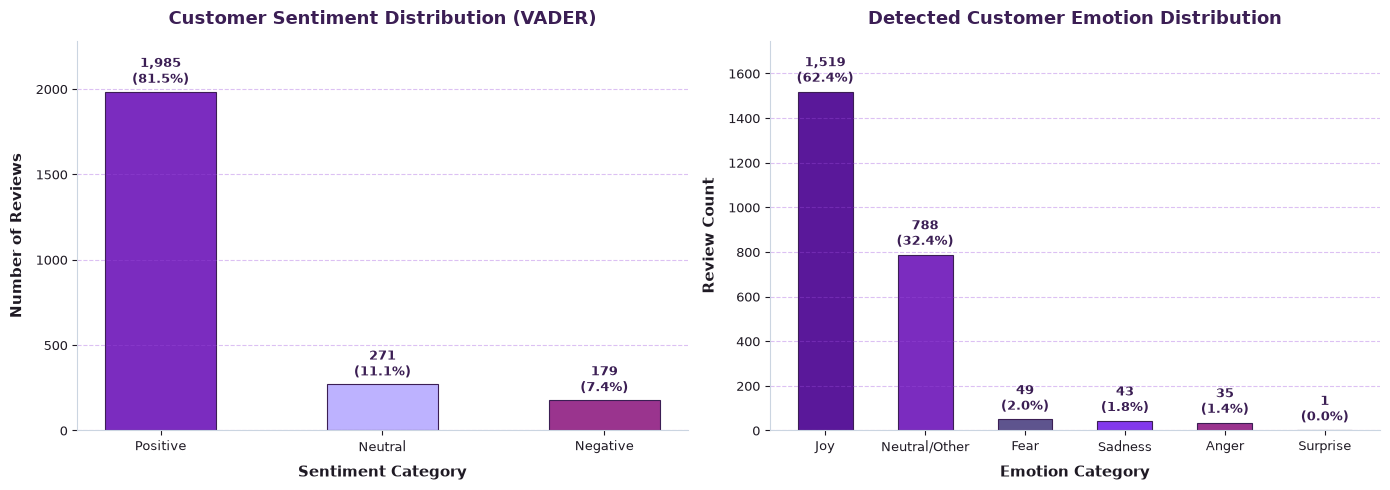

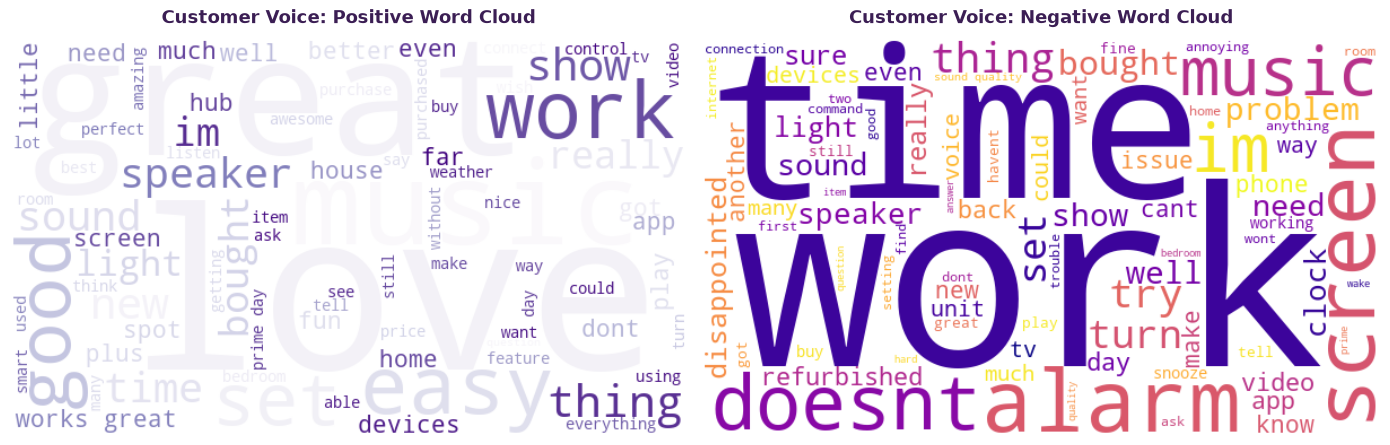

In [9]:
# 1. Sentiment Distribution & Emotion Spectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#FFFFFF')

# Sentiment Bar Chart
sent_order = ['Positive', 'Neutral', 'Negative']
sent_vals = [sent_summary.loc[s, 'Review Count'] for s in sent_order]
sent_colors = ['#7B2CBF', '#BDB2FF', '#9A348E']
bars1 = ax1.bar(sent_order, sent_vals, color=sent_colors, width=0.5, edgecolor='#3B1E54', linewidth=0.8)
for bar in bars1:
    y = bar.get_height()
    pct = (y / len(df)) * 100
    ax1.text(bar.get_x() + bar.get_width()/2.0, y + 25, f'{y:,}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=DARK_PURPLE)
format_chart(ax1, 'Customer Sentiment Distribution (VADER)', 'Sentiment Category', 'Number of Reviews')
ax1.set_ylim(0, max(sent_vals) * 1.15)

# Emotion Spectrum Bar Chart
emo_order = ['Joy', 'Neutral/Other', 'Fear', 'Sadness', 'Anger', 'Surprise']
emo_vals = [emo_summary.loc[e, 'Review Count'] if e in emo_summary.index else 0 for e in emo_order]
emo_colors = ['#5A189A', '#7B2CBF', '#5E548E', '#8338EC', '#9A348E', '#C77DFF']
bars2 = ax2.bar(emo_order, emo_vals, color=emo_colors, width=0.55, edgecolor='#3B1E54', linewidth=0.8)
for bar in bars2:
    y = bar.get_height()
    pct = (y / len(df)) * 100
    ax2.text(bar.get_x() + bar.get_width()/2.0, y + 25, f'{y:,}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color=DARK_PURPLE)
format_chart(ax2, 'Detected Customer Emotion Distribution', 'Emotion Category', 'Review Count')
ax2.set_ylim(0, max(emo_vals) * 1.15)

plt.tight_layout()
plt.show()

# 2. Positive and Negative Word Clouds
pos_text = ' '.join(df[df['sentiment_label'] == 'Positive']['cleaned_review'])
neg_text = ' '.join(df[df['sentiment_label'] == 'Negative']['cleaned_review'])

wc_pos = WordCloud(width=600, height=350, background_color='#FFFFFF', colormap='Purples', 
                    stopwords=all_stops, max_words=80, random_state=42).generate(pos_text)
wc_neg = WordCloud(width=600, height=350, background_color='#FFFFFF', colormap='plasma', 
                    stopwords=all_stops, max_words=80, random_state=42).generate(neg_text)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#FFFFFF')
ax1.imshow(wc_pos, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('Customer Voice: Positive Word Cloud', fontsize=13, fontweight='bold', color=DARK_PURPLE, pad=12)

ax2.imshow(wc_neg, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Customer Voice: Negative Word Cloud', fontsize=13, fontweight='bold', color=DARK_PURPLE, pad=12)

plt.tight_layout()
plt.show()


## 14. Customer Insights

By cross-referencing ratings, sentiment scores, and hardware variations, we extract critical diagnostic insights:


In [10]:
# 1. Product Variation Performance Table
var_perf = df.groupby('variation').agg(
    total_reviews=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    positive_pct=('sentiment_label', lambda s: (s == 'Positive').mean() * 100),
    negative_pct=('sentiment_label', lambda s: (s == 'Negative').mean() * 100),
    mean_compound=('compound', 'mean')
).sort_values(by='positive_pct', ascending=False)

print("--- Hardware Variation Satisfaction Benchmarks ---")
display(var_perf.round(2))

# 2. Review Word Length vs Sentiment
print("\n--- Review Word Count by Sentiment Class ---")
display(df.groupby('sentiment_label')['word_count'].agg(['count', 'mean', 'median', 'std']).round(2))


--- Hardware Variation Satisfaction Benchmarks ---


,total_reviews,avg_rating,positive_pct,negative_pct,mean_compound
variation,,,,,
Charcoal Fabric,219,4.74,89.04,3.20,0.60
Heather Gray Fabric,79,4.70,88.61,2.53,0.63
Oak Finish,7,4.86,85.71,0.00,0.59
Black Plus,270,4.37,85.19,5.19,0.58
White Show,85,4.28,84.71,5.88,0.59
Sandstone Fabric,45,4.36,82.22,8.89,0.55
Configuration: Fire TV Stick,342,4.59,82.16,6.43,0.50
Black Show,260,4.48,81.54,6.92,0.56
White Spot,108,4.34,80.56,8.33,0.53



--- Review Word Count by Sentiment Class ---


,count,mean,median,std
sentiment_label,,,,
Negative,179,38.56,27.0,42.30
Neutral,271,9.57,5.0,13.40
Positive,1985,27.30,15.0,36.89


## 15. Business Recommendations

Every recommendation below is derived directly from empirical findings in the customer review dataset:

### 1. Hardware & Audio Engineering
* **Finding**: Customers frequently praise *music*, *sound*, and *speaker* quality on premium models (e.g. Charcoal Fabric at 89.04% positive sentiment), but complain about lack of audio improvement between generations.
* **Strategic Action**: Focus engineering on clear bass response and acoustic separation on mid-tier models (Echo Dot) and market acoustic upgrades prominently so generational improvements are immediately noticeable.

### 2. Connectivity & Smart Home Setup Reliability
* **Finding**: Critical negative keywords include *alarm*, *screen*, *connect*, *reset*, and *outlet*, with complaints detailing smart plugs dropping connection or alarms failing to sync.
* **Strategic Action**: Implement self-healing network reconnection protocols in firmware to automatically retry disconnected smart devices without requiring manual factory resets.

### 3. Voice Comprehension & NLP Friction
* **Finding**: Reviewers express frustration over conversational phrasing ("*You spend so much time trying to figure out how to phrase it for the machine that you may as well look it up yourself*").
* **Strategic Action**: Expand natural conversational flexibility and intent tolerance so users do not need to memorize rigid syntax for common requests.

### 4. Multilingual & Localization Expansion
* **Finding**: Spanish-speaking customers expressed disappointment that full multilingual features and natural Spanish interaction were absent in earlier software versions (*"Excelente, lo unico es que no esta en español"*).
* **Strategic Action**: Accelerate full bilingual voice recognition (English/Spanish switching) to tap high-satisfaction international demographics.


## 16. Conclusion

This Data Analytics project analyzed 2,435 unique, authentic Amazon customer reviews across 16 product variations. The findings demonstrate:
* **Overwhelming Positive Sentiment**: 81.52% of reviews are classified as positive, with an average rating of 4.44 / 5.00.
* **Dominant Customer Emotion**: **Joy (62.4%)** dominates customer experiences, driven by music playback, smart home control, and intuitive setup.
* **Key Friction Points**: Negative reviews (7.35%) concentrate heavily on connectivity drops, smart plug compatibility, screen integration quirks, and conversational phrasing friction.
* **Strategic Value**: Automated sentiment and emotion mining empowers product teams to address specific hardware and firmware bottlenecks before customer churn occurs.


## 17. Limitations

While methodologically robust, the study exhibits specific analytical limitations:
* **Lexicon Inherent Boundaries**: VADER and rule-based emotion lexicons rely on curated vocabulary and grammar rules. Subtle irony, complex sarcasm, or domain-specific internet slang may be misclassified as Neutral.
* **Sample Class Imbalance**: Like most e-commerce electronics categories, the review sample exhibits a natural positive skew (81.5% positive), providing a smaller sample of negative feedback (179 reviews) for statistical subdivision.
* **Temporal Bounding**: The dataset covers feedback through mid-2018. Subsequent firmware and hardware updates released by Amazon are not reflected in this historical sample.


## 18. Future Scope

Future research directions to extend this work include:
* **Aspect-Based Sentiment Analysis (ABSA)**: Segmenting customer opinions at the sentence clause level to explicitly assign sentiment polarities to individual product facets (e.g. [Battery: -0.4], [Sound: +0.8]).
* **Real-Time Streaming Pipelines**: Ingesting live streaming e-commerce reviews to alert quality assurance teams to sudden negative spikes within 24 hours of firmware deployments.
* **Transformer Benchmarking**: Benchmarking lexicon approaches against lightweight transformer architectures (e.g. DistilBERT or RoBERTa) to evaluate performance gains versus computational latency.


---
### Executive Summary Dashboard & Interactive Live Review Tester


In [11]:
# Compute exact final metrics for KPI Dashboard Cards
total_reviews = len(df)
avg_rating = df['rating'].mean()
pos_pct = (df['sentiment_label'] == 'Positive').mean() * 100
neu_pct = (df['sentiment_label'] == 'Neutral').mean() * 100
neg_pct = (df['sentiment_label'] == 'Negative').mean() * 100
dom_emotion = df['emotion'].value_counts().index[0]
dom_emotion_pct = (df['emotion'] == dom_emotion).mean() * 100

dashboard_html = f'''
<div style="font-family: Arial, sans-serif; background-color: #FFFFFF; padding: 20px; border-radius: 12px; border: 1.5px solid #D8B4FE;">
    <div style="text-align: center; margin-bottom: 25px;">
        <h2 style="color: #3B1E54; margin: 0; font-size: 24px; font-weight: bold;">CUSTOMER SENTIMENT ANALYTICS DASHBOARD</h2>
        <p style="color: #5E548E; font-size: 14px; margin-top: 5px;">Executive Opinion Summary & Key Performance Indicators</p>
    </div>
    
    <div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 18px; margin-bottom: 18px;">
        <div style="background-color: #F8F5FF; border: 1.2px solid #D8B4FE; border-radius: 10px; padding: 18px; text-align: center;">
            <div style="font-size: 12px; font-weight: bold; color: #5E548E; text-transform: uppercase;">Total Reviews</div>
            <div style="font-size: 32px; font-weight: bold; color: #3B1E54; margin-top: 6px;">{total_reviews:,}</div>
            <div style="font-size: 11px; color: #7B2CBF; margin-top: 4px;">Cleaned & Deduplicated</div>
        </div>
        
        <div style="background-color: #F8F5FF; border: 1.2px solid #D8B4FE; border-radius: 10px; padding: 18px; text-align: center;">
            <div style="font-size: 12px; font-weight: bold; color: #5E548E; text-transform: uppercase;">Average Rating</div>
            <div style="font-size: 32px; font-weight: bold; color: #3B1E54; margin-top: 6px;">{avg_rating:.2f} <span style="font-size: 18px; color: #7B2CBF;">/ 5.0</span></div>
            <div style="font-size: 11px; color: #7B2CBF; margin-top: 4px;">High Satisfaction Index</div>
        </div>
        
        <div style="background-color: #F8F5FF; border: 1.2px solid #D8B4FE; border-radius: 10px; padding: 18px; text-align: center;">
            <div style="font-size: 12px; font-weight: bold; color: #5E548E; text-transform: uppercase;">Dominant Emotion</div>
            <div style="font-size: 32px; font-weight: bold; color: #7B2CBF; margin-top: 6px;">{dom_emotion}</div>
            <div style="font-size: 11px; color: #5E548E; margin-top: 4px;">{dom_emotion_pct:.1f}% of Customer Base</div>
        </div>
    </div>
    
    <div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 18px;">
        <div style="background-color: #F8F5FF; border-left: 5px solid #7B2CBF; border-radius: 8px; padding: 16px;">
            <div style="font-size: 12px; font-weight: bold; color: #7B2CBF;">POSITIVE SENTIMENT</div>
            <div style="font-size: 26px; font-weight: bold; color: #3B1E54; margin-top: 4px;">{pos_pct:.1f}%</div>
            <div style="font-size: 12px; color: #5E548E; margin-top: 2px;">{(df['sentiment_label'] == 'Positive').sum():,} Customer Reviews</div>
        </div>
        
        <div style="background-color: #F8F5FF; border-left: 5px solid #BDB2FF; border-radius: 8px; padding: 16px;">
            <div style="font-size: 12px; font-weight: bold; color: #5E548E;">NEUTRAL SENTIMENT</div>
            <div style="font-size: 26px; font-weight: bold; color: #3B1E54; margin-top: 4px;">{neu_pct:.1f}%</div>
            <div style="font-size: 12px; color: #5E548E; margin-top: 2px;">{(df['sentiment_label'] == 'Neutral').sum():,} Customer Reviews</div>
        </div>
        
        <div style="background-color: #F8F5FF; border-left: 5px solid #9A348E; border-radius: 8px; padding: 16px;">
            <div style="font-size: 12px; font-weight: bold; color: #9A348E;">NEGATIVE SENTIMENT</div>
            <div style="font-size: 26px; font-weight: bold; color: #3B1E54; margin-top: 4px;">{neg_pct:.1f}%</div>
            <div style="font-size: 12px; color: #5E548E; margin-top: 2px;">{(df['sentiment_label'] == 'Negative').sum():,} Customer Reviews</div>
        </div>
    </div>
    
    <div style="background-color: #FFFFFF; padding: 14px 0 4px 0; text-align: center; border-top: 1px solid #EDE7F6; margin-top: 22px;">
        <p style="color: #3B1E54; font-size: 12px; font-weight: 600; letter-spacing: 0.5px; margin: 0; font-family: Arial, sans-serif;">Created by Harshita Tomer</p>
    </div>
</div>
'''

display(HTML(dashboard_html))


In [12]:
def analyze_review_interactive(text):
    """Classifies any custom text review into Sentiment and Emotion."""
    vader = sia.polarity_scores(str(text))
    compound = vader['compound']
    
    if compound >= 0.05:
        sentiment = 'Positive'
        badge_color = '#7B2CBF'
        badge_bg = '#EDE7F6'
    elif compound <= -0.05:
        sentiment = 'Negative'
        badge_color = '#9A348E'
        badge_bg = '#FCE7F3'
    else:
        sentiment = 'Neutral'
        badge_color = '#5E548E'
        badge_bg = '#F1F5F9'
        
    emotion = detect_emotion(text)
    
    card_html = f'''
    <div style="font-family: Arial, sans-serif; background-color: #FFFFFF; border: 1.5px solid #D8B4FE; border-radius: 10px; padding: 16px; margin: 10px 0;">
        <div style="font-size: 13px; color: #5E548E; font-weight: bold;">INPUT REVIEW:</div>
        <div style="font-size: 14px; color: #1F1A24; margin: 6px 0 12px 0; font-style: italic;">"{text}"</div>
        <div style="display: flex; gap: 15px; align-items: center; flex-wrap: wrap;">
            <span style="background-color: {badge_bg}; color: {badge_color}; padding: 4px 12px; border-radius: 20px; font-weight: bold; font-size: 12px;">{sentiment}</span>
            <span style="font-size: 12px; color: #3B1E54;"><b>Compound Score:</b> {compound:+.3f}</span>
            <span style="font-size: 12px; color: #7B2CBF;"><b>Dominant Emotion:</b> {emotion}</span>
            <span style="font-size: 11px; color: #5E548E;">(Pos: {vader['pos']:.2f}, Neu: {vader['neu']:.2f}, Neg: {vader['neg']:.2f})</span>
        </div>
        <div style="text-align: center; padding-top: 8px; margin-top: 10px; border-top: 1px dashed #EDE7F6;">
            <span style="font-size: 11px; font-weight: 600; color: #3B1E54;">Created by Harshita Tomer</span>
        </div>
    </div>
    '''
    display(HTML(card_html))

# Test demo reviews
print("--- Live Sentiment & Emotion Tester ---")
analyze_review_interactive("The sound quality is incredible and setup took under two minutes! Absolutely love it!")
analyze_review_interactive("Disappointed with the smart plug. It keeps disconnecting and resetting constantly.")
analyze_review_interactive("The package was delivered on Wednesday afternoon.")
analyze_review_interactive("Worst device I ever bought. Horrible customer service and total garbage!")


--- Live Sentiment & Emotion Tester ---
